# L2p8_m9: masked tSZ power spectra across eight lightcones

NaMaster mask-decoupled bandpowers (same pipeline as notebook 09 / L1 script):
5×θ₅₀₀ holes around clusters with `q_from_mz > q_cut`, C1 0.5° apodization,
Δℓ=30 bins to ℓ_max=6000.

Map cache: `data/bandpowers_L2p8_m9_multilc/masked_tsz_ps.npz`  
Theory: `data/theory_masked_tsz_ps_B135.npz` — **B=1.0 A10** (flamingo D3A + nb09 SNR) and **B=1.35** (q_from_mz completeness)  
Rebuild maps: `python scripts/compute_masked_tsz_ps_L2p8_m9_multilc.py`  
Rebuild theory: `python scripts/export_masked_tsz_theory_B135.py`

In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 8,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})

REPO = Path("/scratch/scratch-lxu/flamingo_repo")
DATA_NPZ = REPO / "data/bandpowers_L2p8_m9_multilc/masked_tsz_ps.npz"
THEORY_NPZ = REPO / "data/theory_masked_tsz_ps_B135.npz"
FIG_DIR = REPO / "figures/nb36_l2p8_multilc_masked_tsz_ps"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TH_LABEL_B135 = r"hmfast ($B=1.35$)"
TH_LABEL_B1 = r"hmfast ($B=1.0$, A10)"

ELL_MIN = 100
CUTS = [
    ("fullsky", "Full sky", None),
    ("qgt50", r"$q > 50$", 0),
    ("qgt20", r"$q > 20$", 1),
    ("qgt10", r"$q > 10$", 2),
    ("qgt5", r"$q > 5$", 3),
]
LC_COLORS = plt.cm.viridis(np.linspace(0.15, 0.85, 8))

In [10]:
d = np.load(DATA_NPZ, allow_pickle=True)
ellb = d["ellb"]
lcs = d["lightcones"].astype(int)
dl_full = d["dl_fullsky"]
dl_masked = d["dl_masked"]
n_det = d["n_detected"]

th = np.load(THEORY_NPZ)
dl_th_full = th["dl_fullsky_b135"]
dl_th_masked = th["dl_masked_b135"]
dl_th_full_b1 = th["dl_fullsky_b1"]
dl_th_masked_b1 = th["dl_masked_b1"]

sel = ellb >= ELL_MIN
ell_plot = ellb[sel]
print(f"loaded {DATA_NPZ.name}: {len(lcs)} lightcones, {sel.sum()} ell bins >= {ELL_MIN}")
print(f"loaded theory {THEORY_NPZ.name}  A_SZ={float(th['A_SZ']):.6f}  B={float(th['B'])}")
print("N(q>5) per lc:", dict(zip(lcs, n_det[:, 3])))

loaded masked_tsz_ps.npz: 8 lightcones, 196 ell bins >= 100
loaded theory theory_masked_tsz_ps_B135.npz  A_SZ=-4.051178  B=1.35
N(q>5) per lc: {np.int64(0): np.int64(1155), np.int64(1): np.int64(1201), np.int64(2): np.int64(1121), np.int64(3): np.int64(1165), np.int64(4): np.int64(1116), np.int64(5): np.int64(1155), np.int64(6): np.int64(1135), np.int64(7): np.int64(1097)}


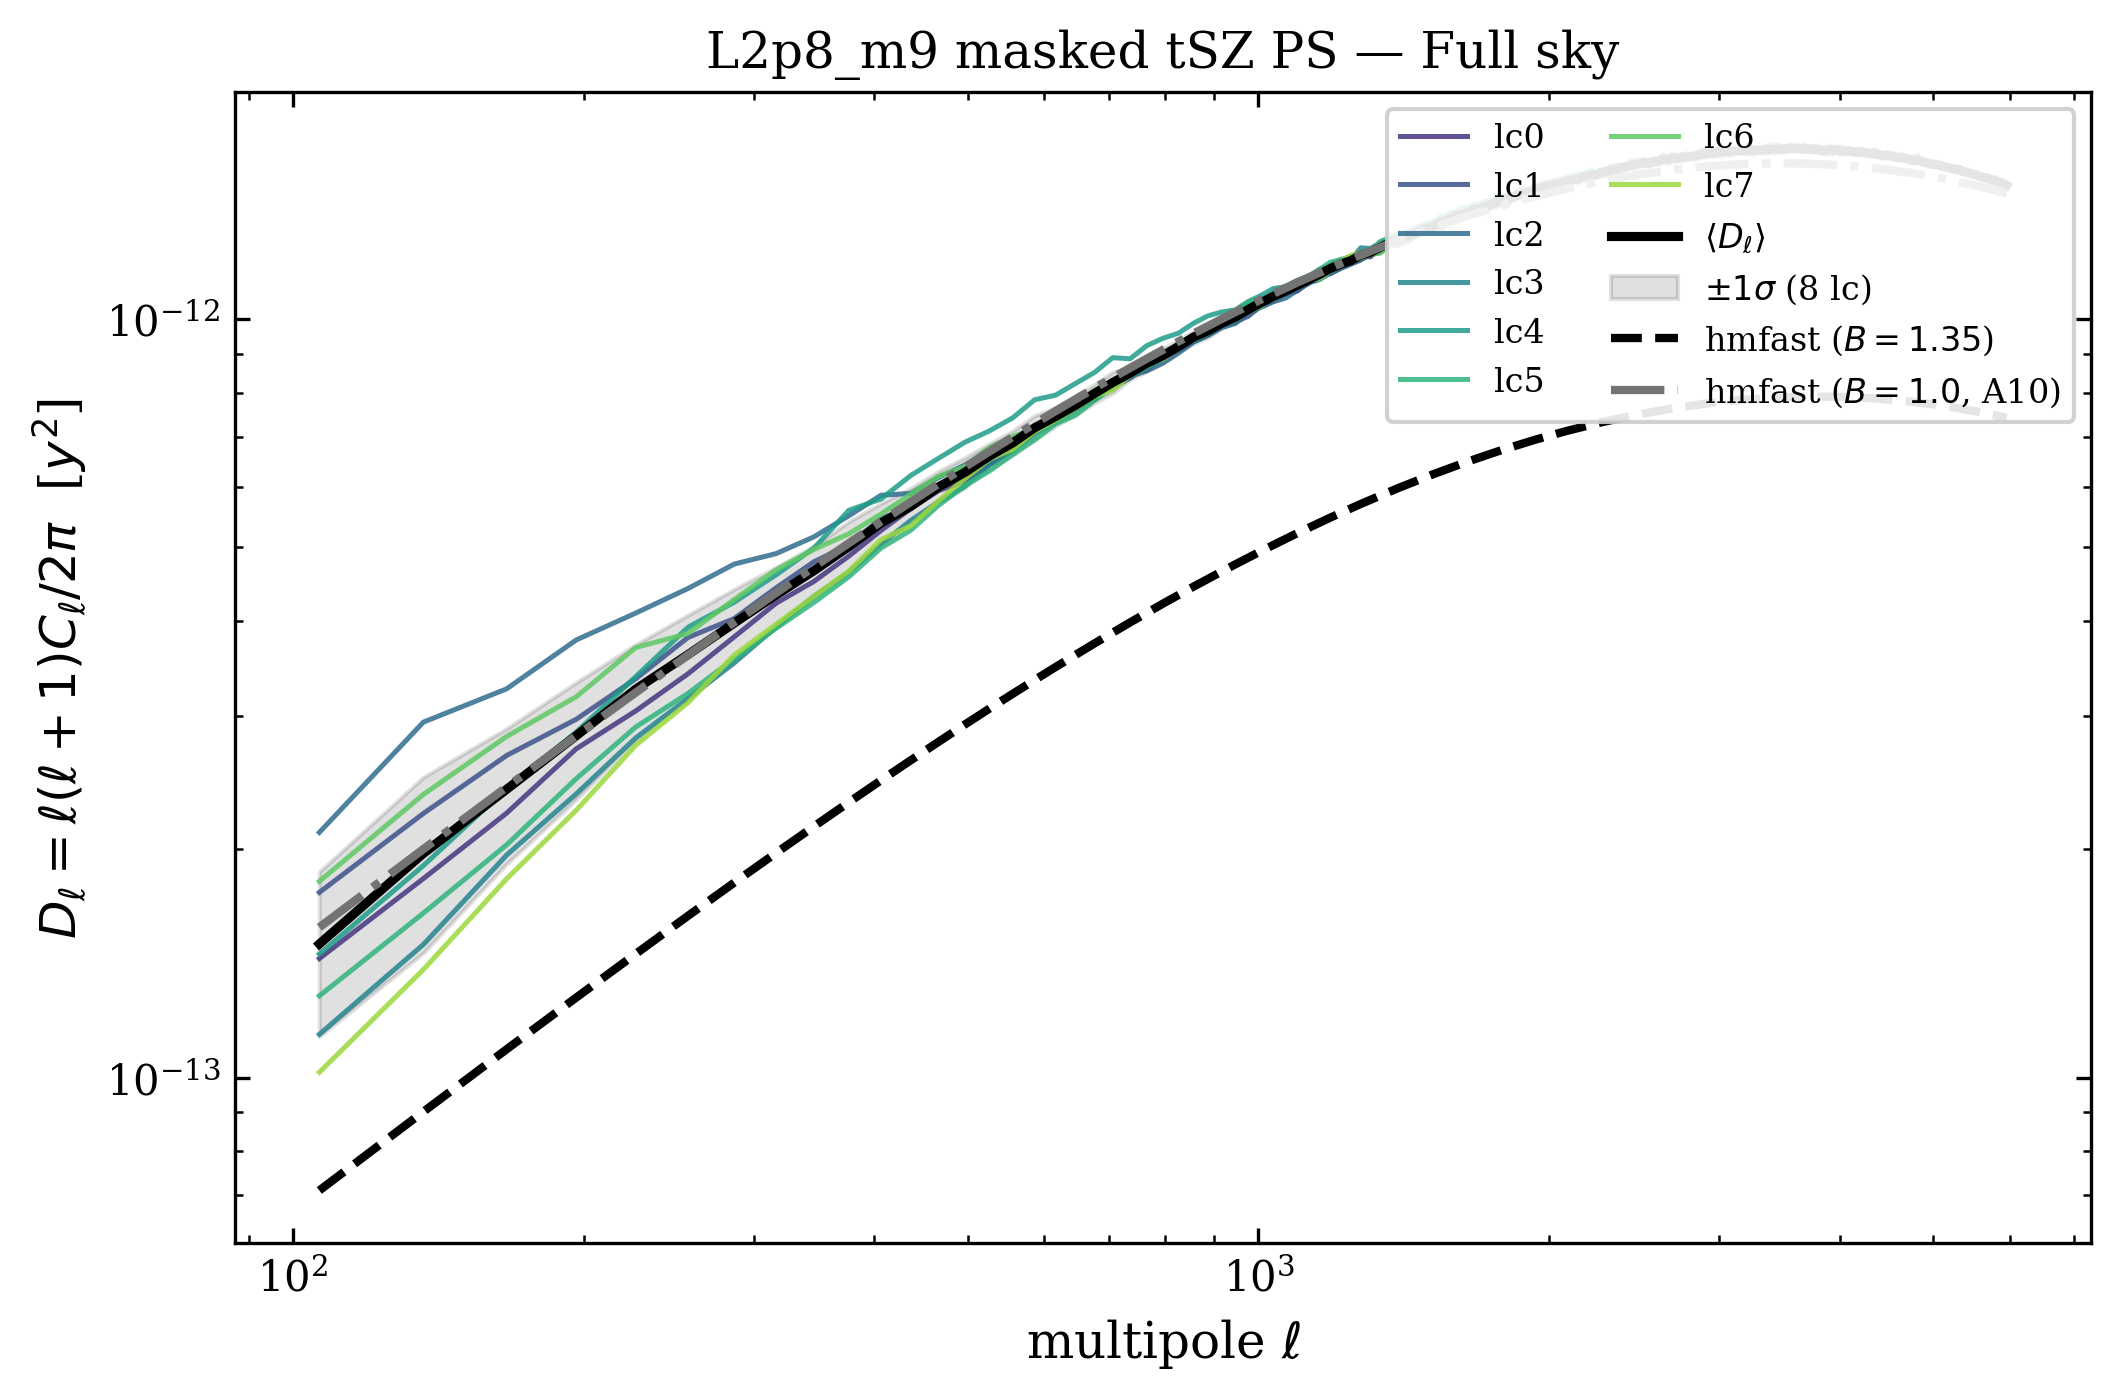

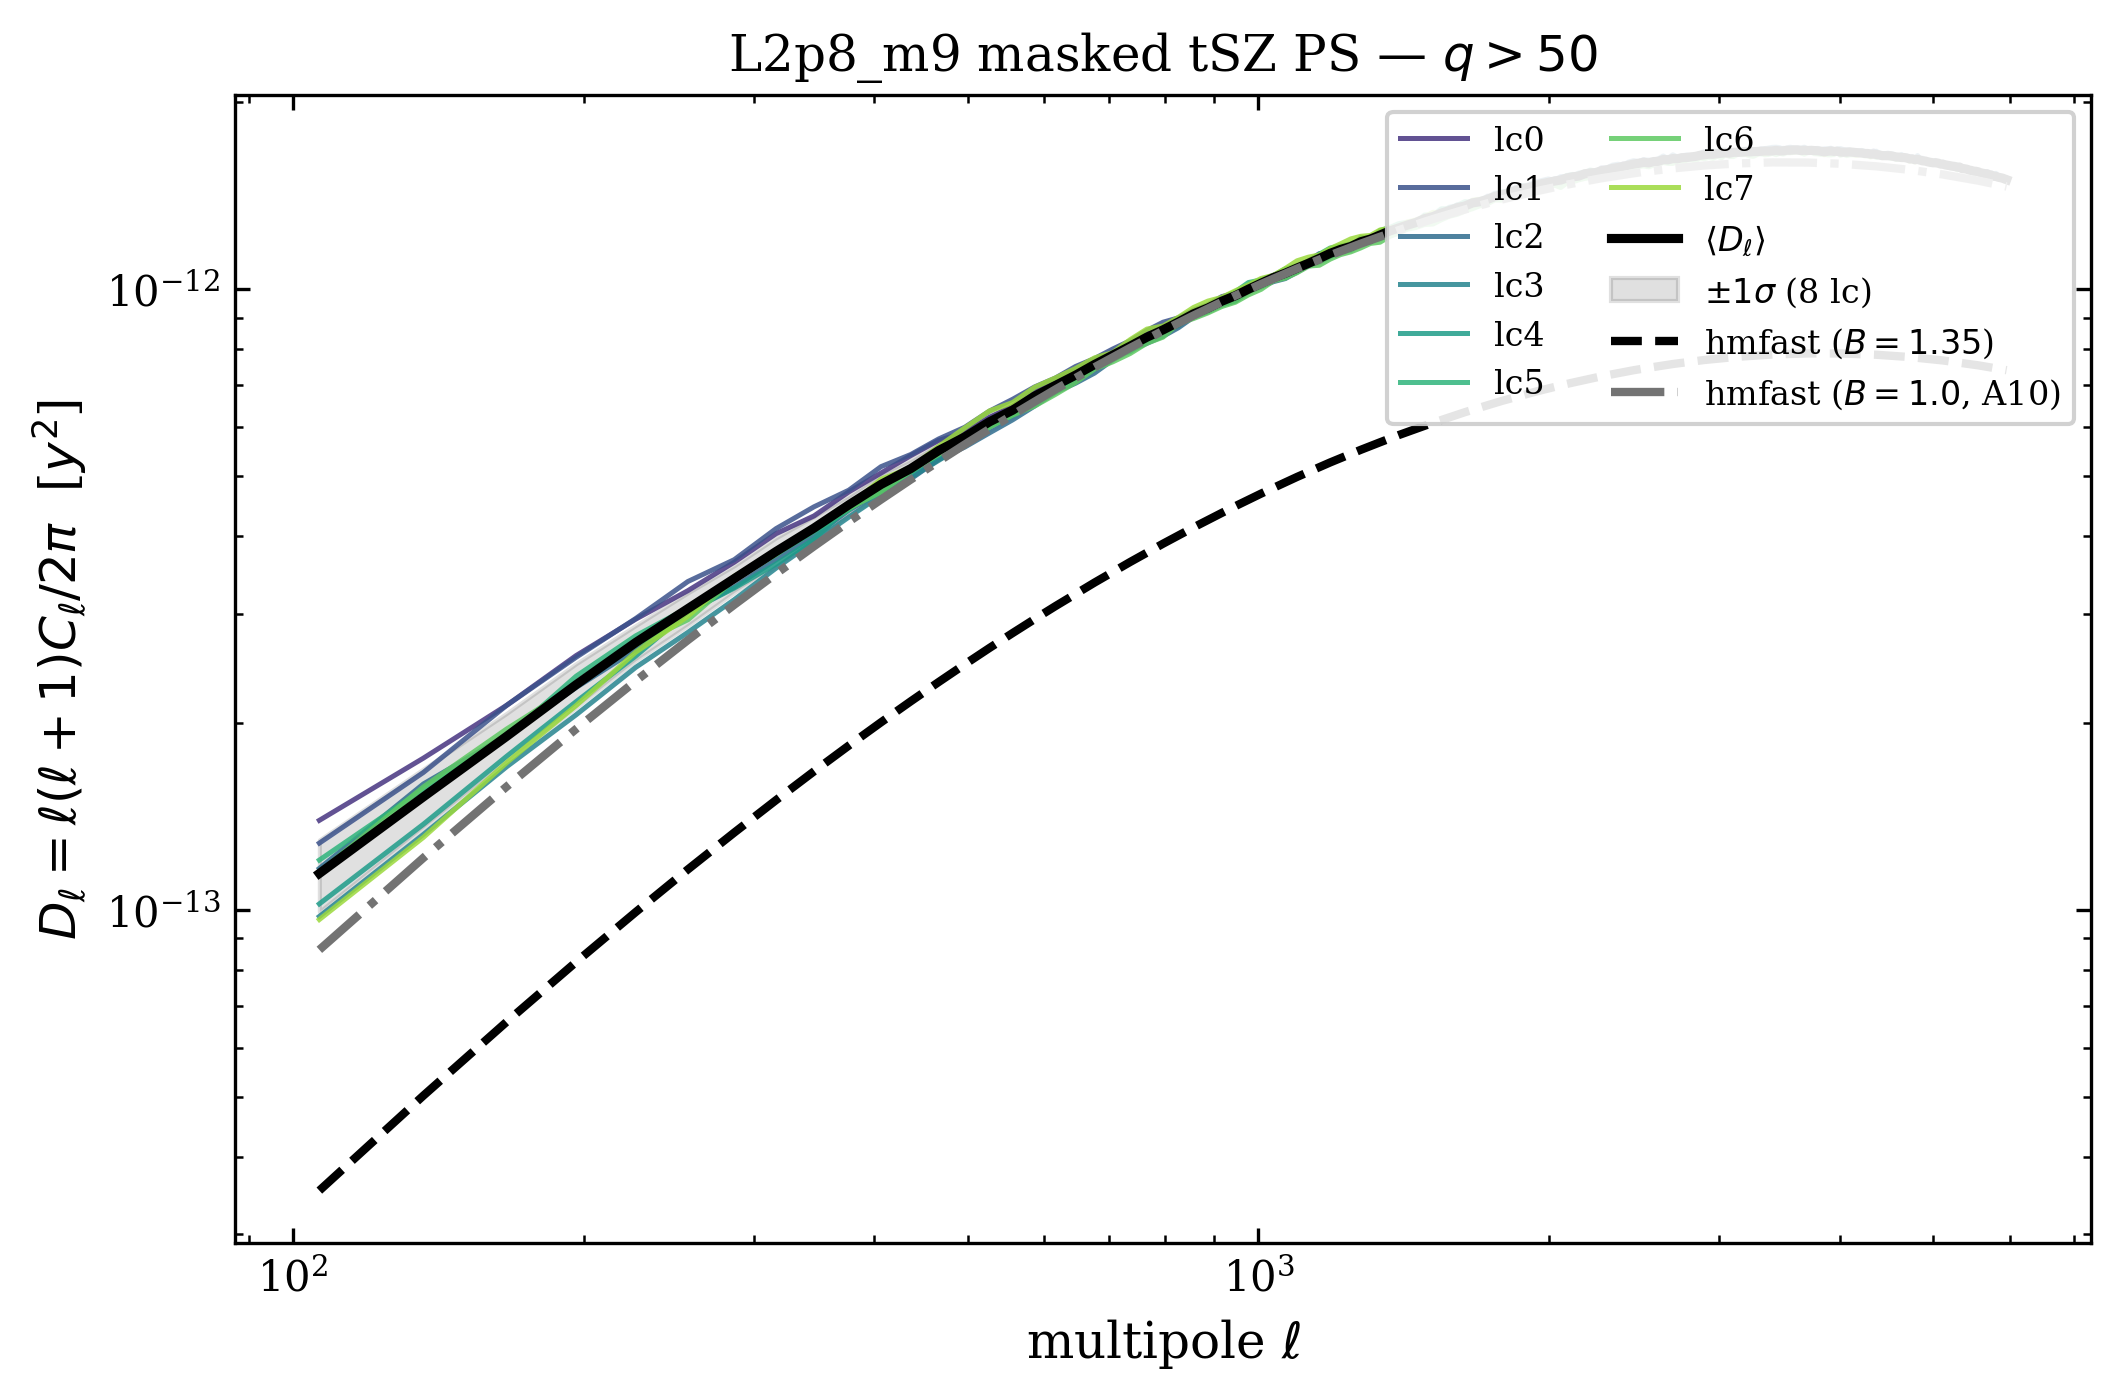

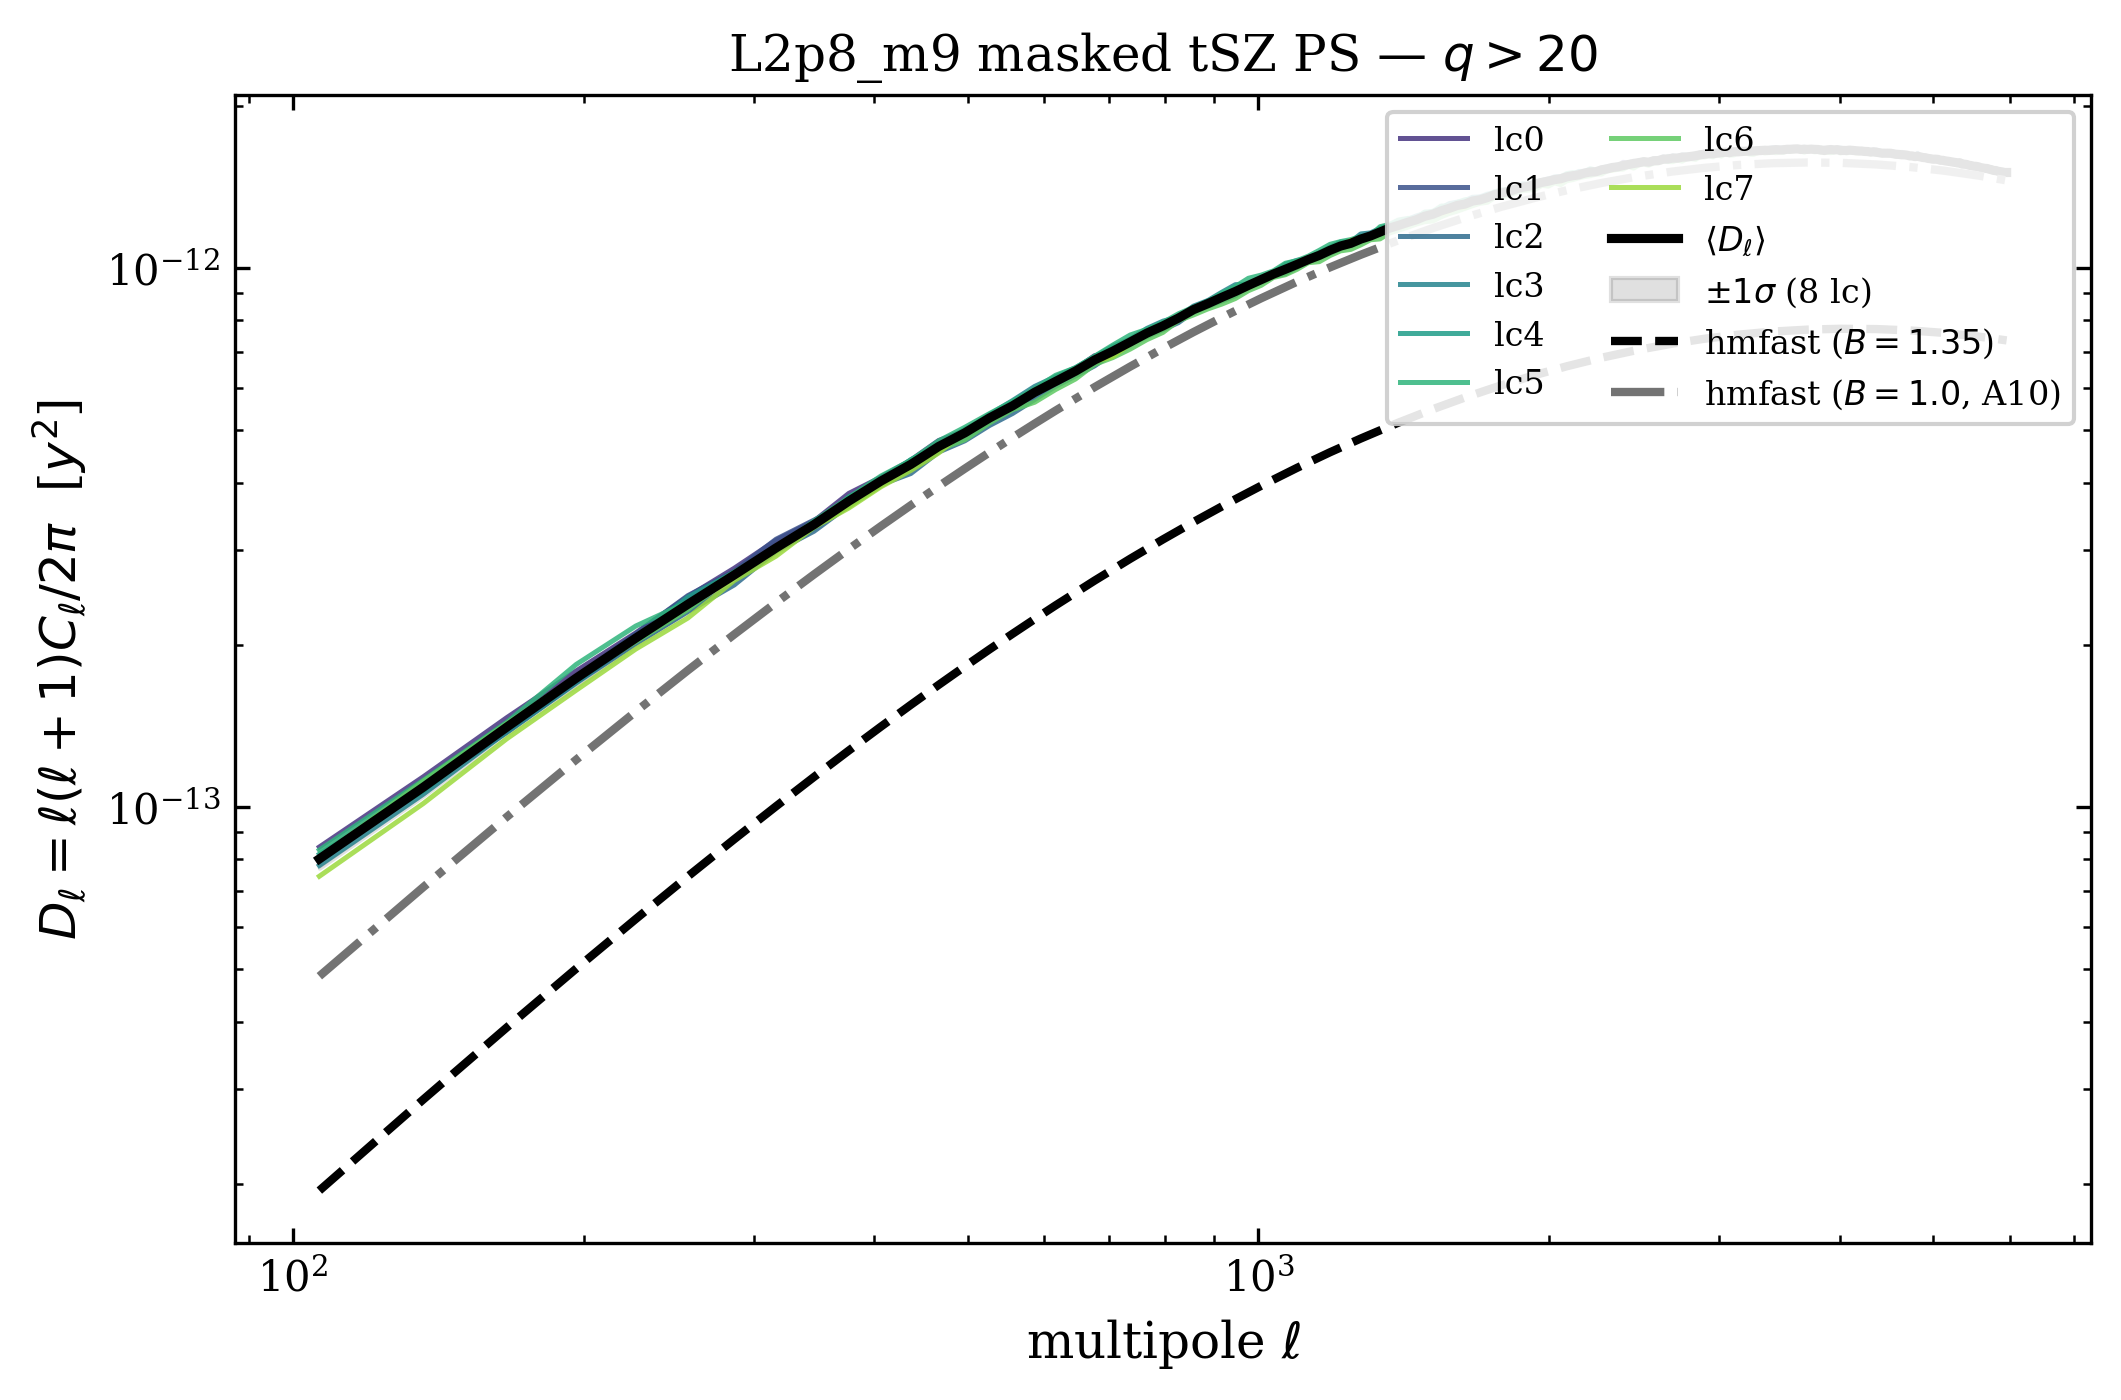

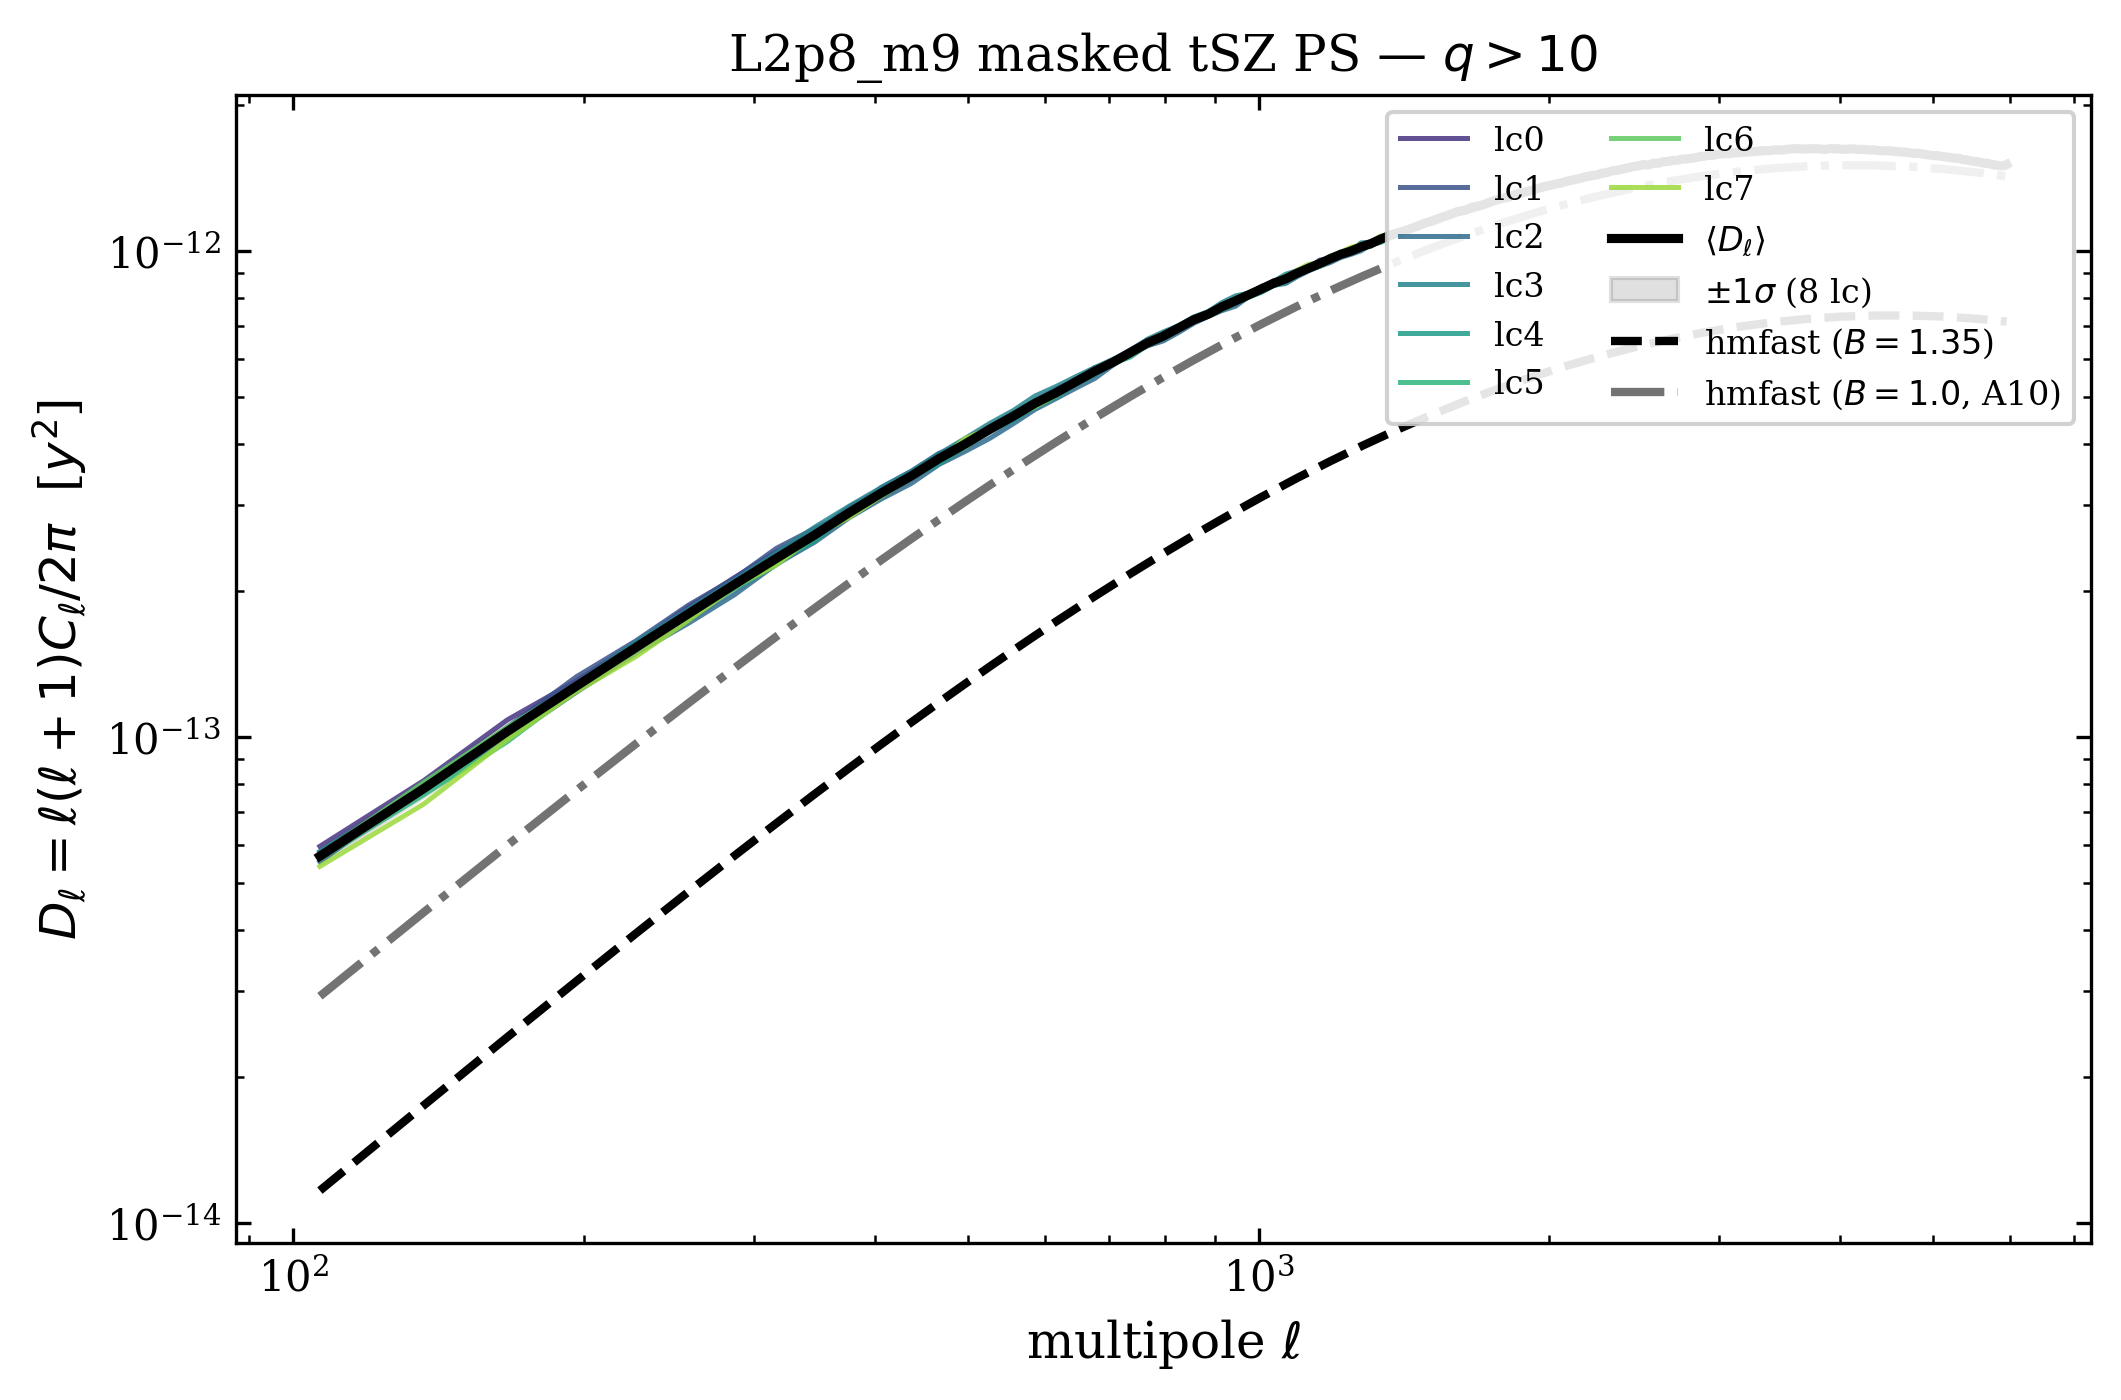

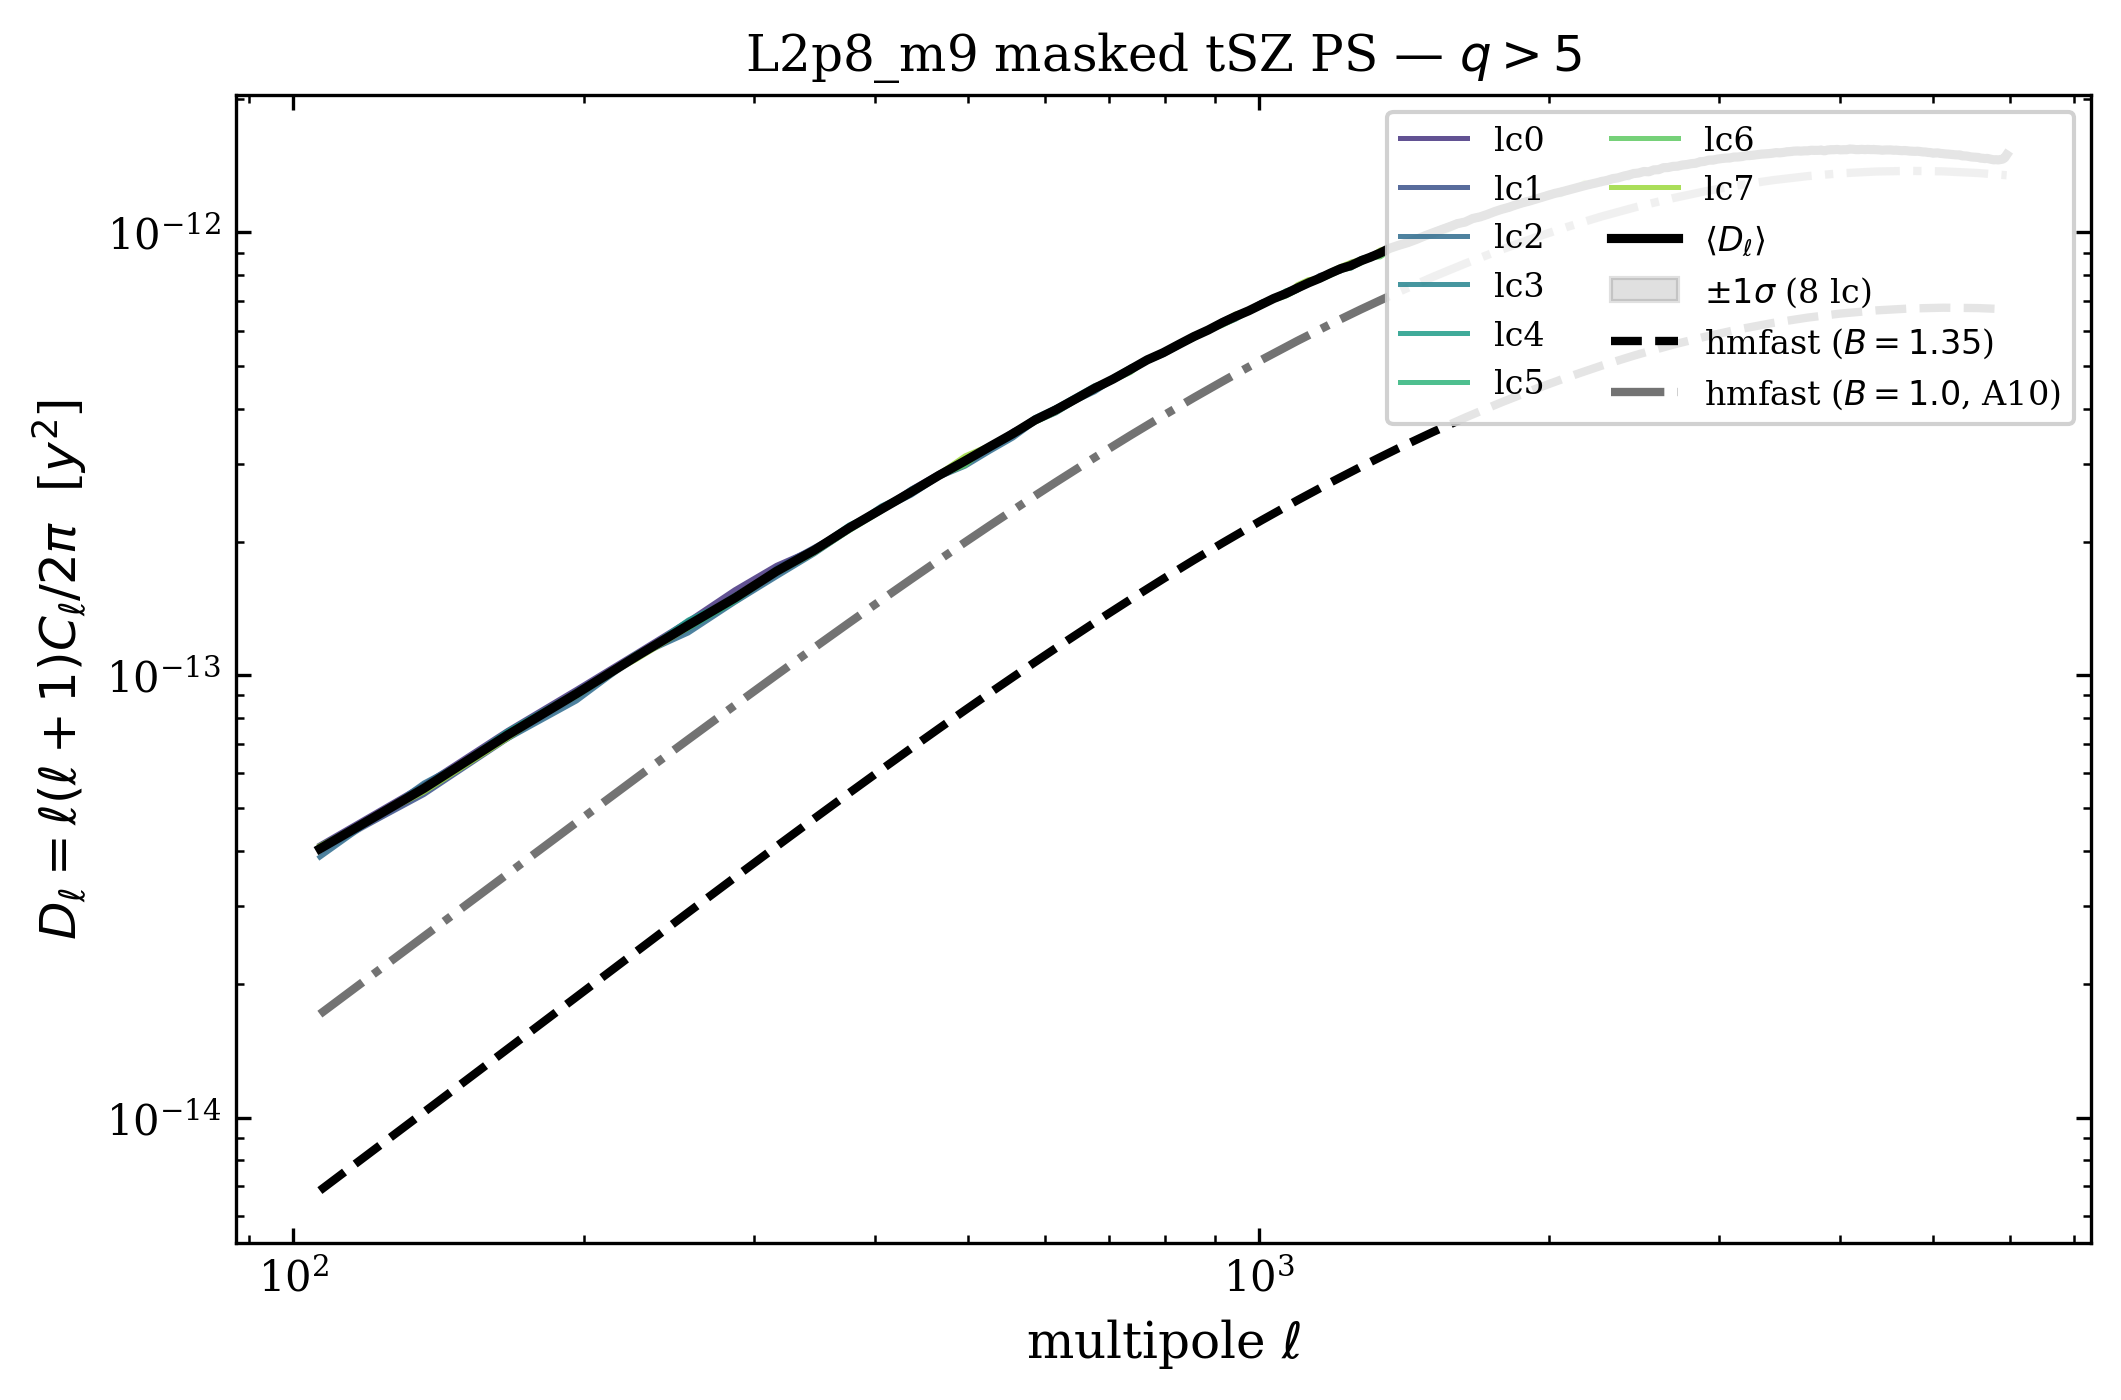

In [11]:
def dl_for_cut(ic):
    if ic is None:
        return dl_full
    return dl_masked[:, ic]


def dl_th_for_cut(ic):
    if ic is None:
        return dl_th_full
    return dl_th_masked[ic]


def dl_th_b1_for_cut(ic):
    if ic is None:
        return dl_th_full_b1
    return dl_th_masked_b1[ic]


for tag, title, ic in CUTS:
    dl_lc = dl_for_cut(ic)
    mean = dl_lc[:, sel].mean(axis=0)
    std = dl_lc[:, sel].std(axis=0, ddof=1)

    fig, ax = plt.subplots(figsize=(7.2, 4.8))
    for i, lc in enumerate(lcs):
        ax.loglog(
            ell_plot, dl_lc[i, sel],
            color=LC_COLORS[i], lw=1.2, alpha=0.85,
            label=f"lc{lc}",
        )
    ax.loglog(ell_plot, mean, color="k", lw=2.2, label=r"$\langle D_\ell \rangle$")
    ax.fill_between(ell_plot, mean - std, mean + std, color="k", alpha=0.12, label=r"$\pm 1\sigma$ (8 lc)")
    ax.loglog(ell_plot, dl_th_for_cut(ic)[sel], "k--", lw=2.0, label=TH_LABEL_B135)
    ax.loglog(ell_plot, dl_th_b1_for_cut(ic)[sel], color="0.45", ls="-.", lw=2.0, label=TH_LABEL_B1)

    ax.set_xlabel(r"multipole $\ell$")
    ax.set_ylabel(r"$D_\ell = \ell(\ell+1)C_\ell/2\pi$  [$y^2$]")
    ax.set_title(f"L2p8_m9 masked tSZ PS — {title}")
    ax.legend(ncol=2, loc="upper right", frameon=True, framealpha=0.9)
    fig.tight_layout()
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"masked_tsz_ps_{tag}.{ext}")
    plt.show()

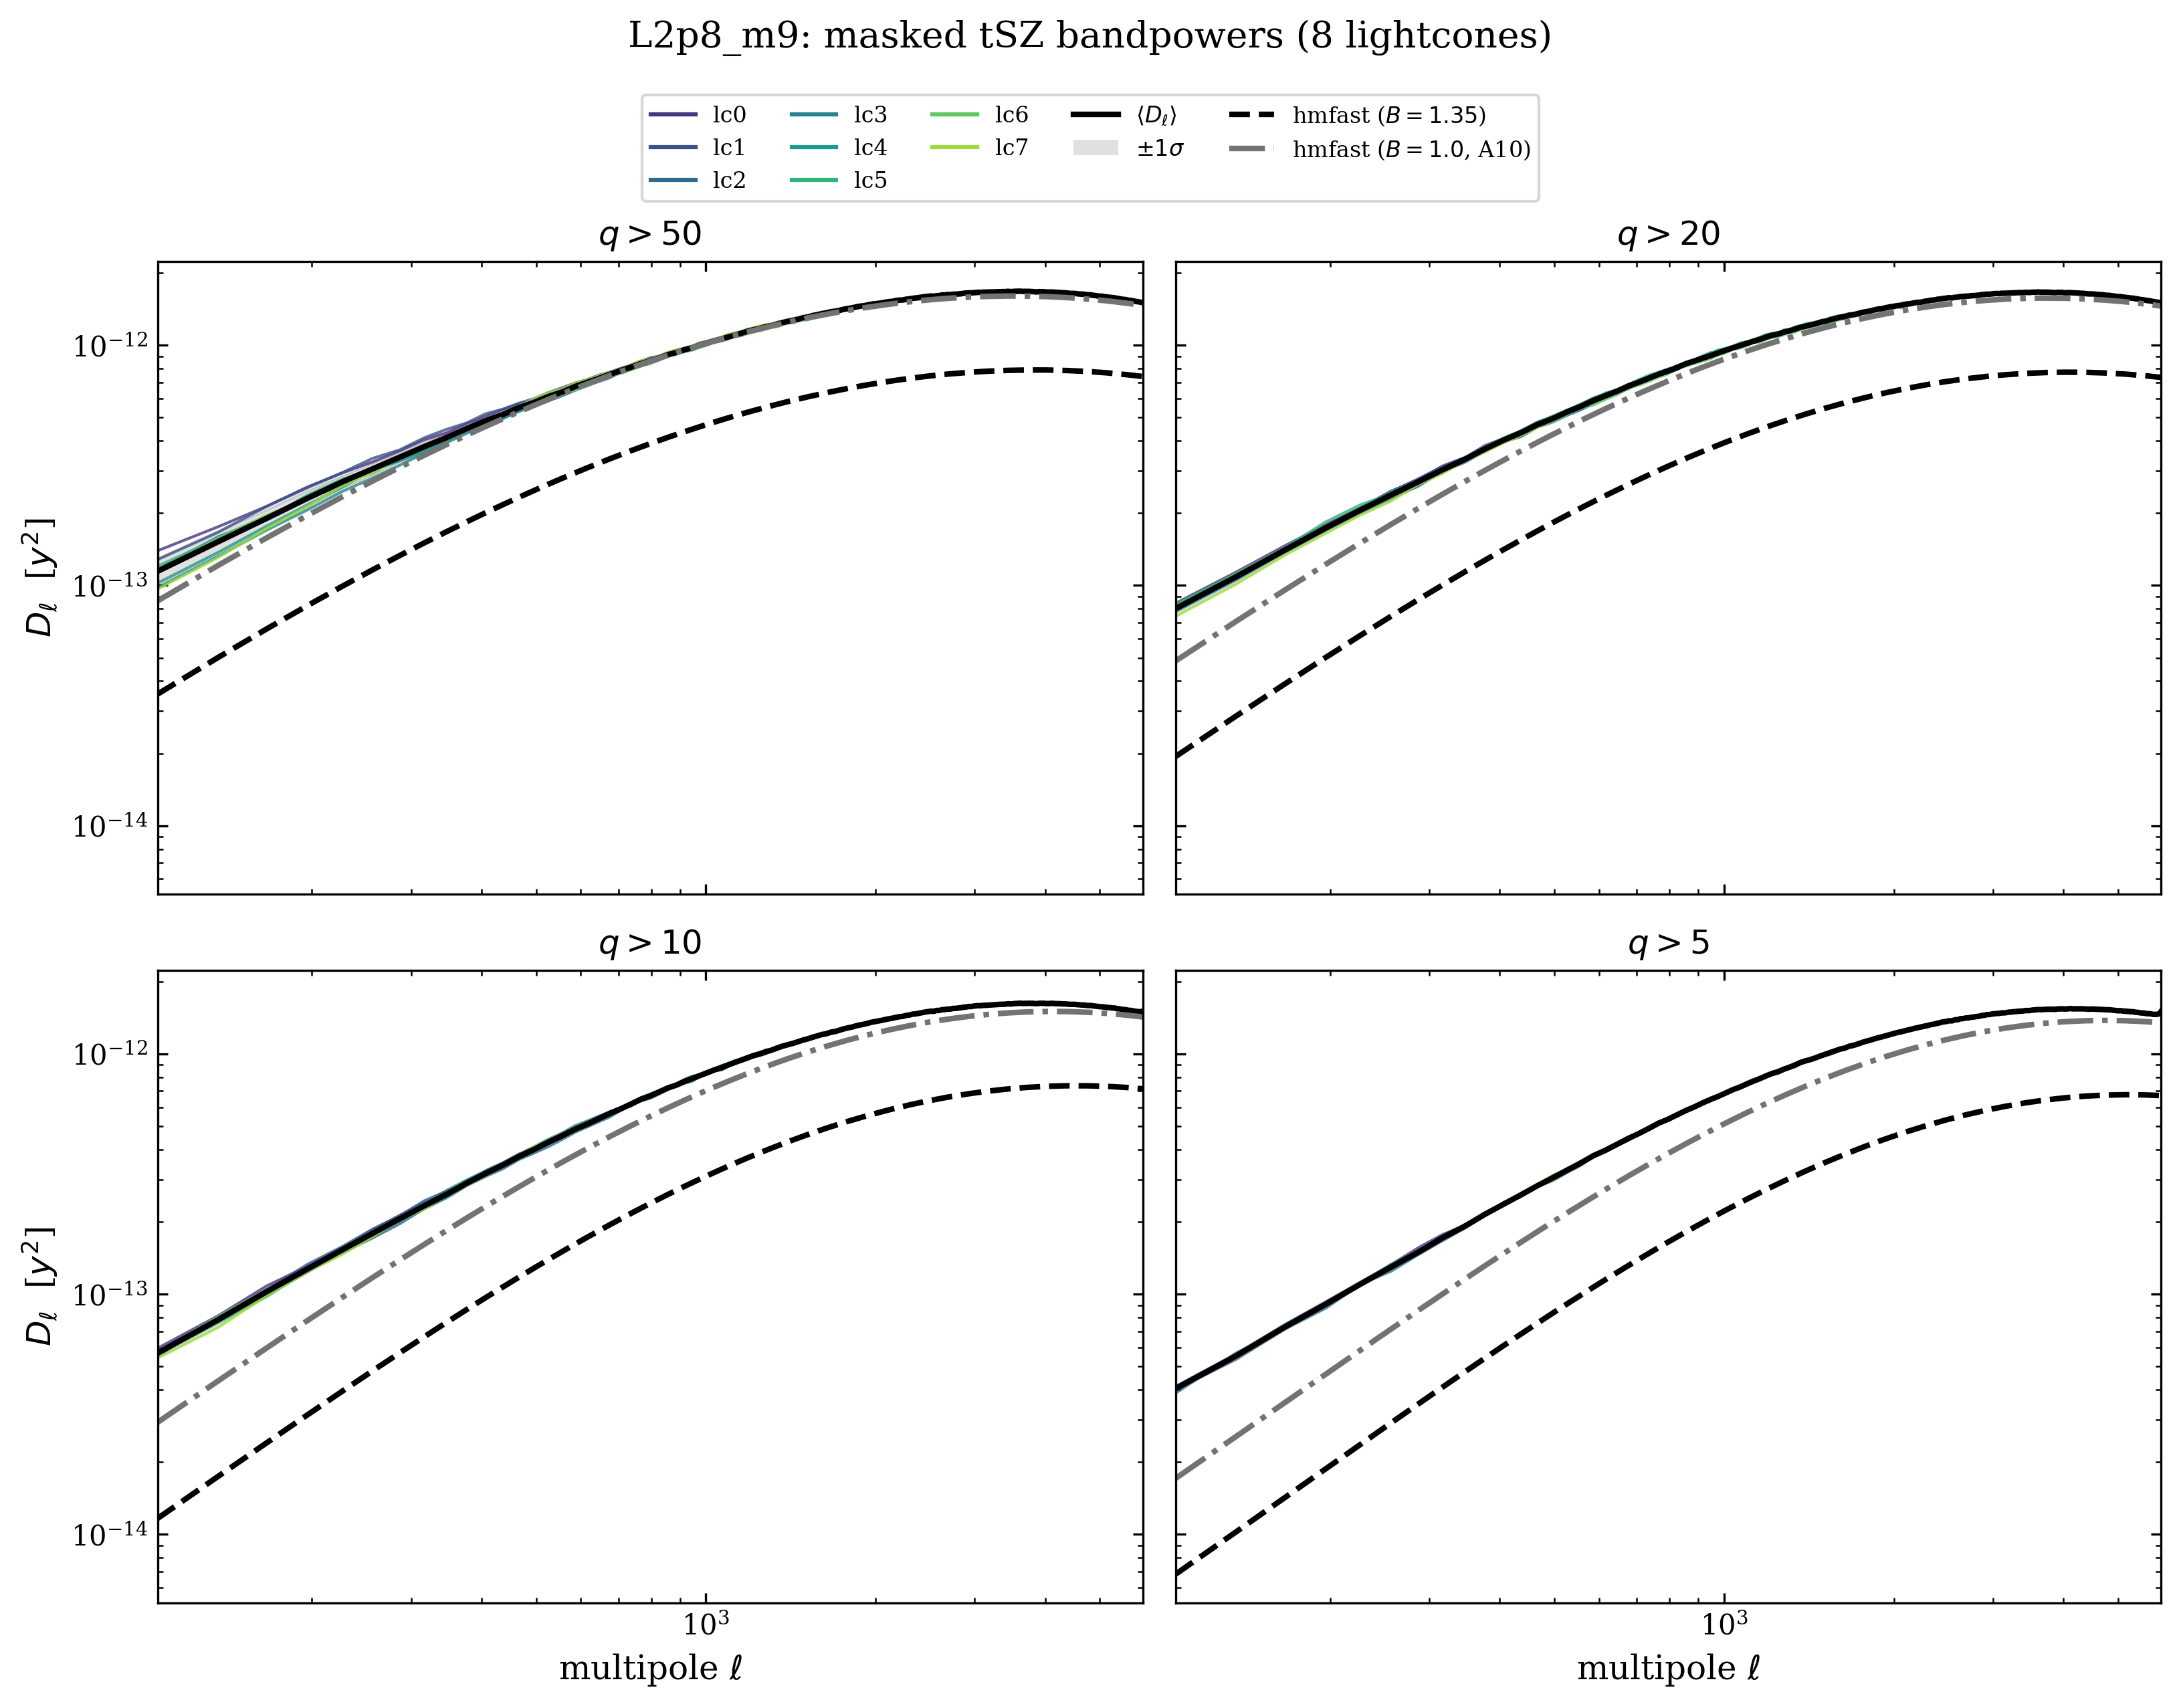

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True)
q_cuts_only = [(tag, title, ic) for tag, title, ic in CUTS if ic is not None]
for ax, (tag, title, ic) in zip(axes.ravel(), q_cuts_only):
    dl_lc = dl_masked[:, ic]
    mean = dl_lc[:, sel].mean(axis=0)
    std = dl_lc[:, sel].std(axis=0, ddof=1)
    for i, lc in enumerate(lcs):
        ax.loglog(ell_plot, dl_lc[i, sel], color=LC_COLORS[i], lw=1.0, alpha=0.8)
    ax.loglog(ell_plot, mean, color="k", lw=2.0)
    ax.fill_between(ell_plot, mean - std, mean + std, color="k", alpha=0.12)
    ax.loglog(ell_plot, dl_th_masked[ic, sel], "k--", lw=2.0)
    ax.loglog(ell_plot, dl_th_masked_b1[ic, sel], color="0.45", ls="-.", lw=2.0)
    ax.set_title(title)
    ax.set_xlim(ell_plot.min(), ell_plot.max())

for ax in axes[1]:
    ax.set_xlabel(r"multipole $\ell$")
for ax in axes[:, 0]:
    ax.set_ylabel(r"$D_\ell$  [$y^2$]")

handles = [plt.Line2D([0], [0], color=LC_COLORS[i], lw=1.5, label=f"lc{lcs[i]}") for i in range(len(lcs))]
handles += [
    plt.Line2D([0], [0], color="k", lw=2, label=r"$\langle D_\ell \rangle$"),
    plt.Rectangle((0, 0), 1, 1, fc="k", alpha=0.12, label=r"$\pm 1\sigma$"),
    plt.Line2D([0], [0], color="k", ls="--", lw=2, label=TH_LABEL_B135),
    plt.Line2D([0], [0], color="0.45", ls="-.", lw=2, label=TH_LABEL_B1),
]
fig.legend(handles=handles, loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.02), fontsize=8)
fig.suptitle("L2p8_m9: masked tSZ bandpowers (8 lightcones)", y=1.06)
fig.tight_layout()
for ext in ("pdf", "png"):
    fig.savefig(FIG_DIR / f"masked_tsz_ps_4panel.{ext}", bbox_inches="tight")
plt.show()